In [2]:
import os
import sys
import numpy as np
import pandas as pd
import nibabel as nib
import nilearn
from nilearn.image import resample_img
from nilearn import plotting
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from nilearn import masking
from natsort import natsorted

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, train_test_split
import matplotlib.pyplot as plt
from sklearn.model_selection import RepeatedStratifiedKFold

from tqdm import tqdm

In [2]:
rois_43 = ['V1v', 
'V1d', 
'V2v', 
'V2d', 
'V3v', 
'V3d', 
'hV4', 
'VO1', 
'VO2', 
'PHC1', 
'PHC2', 
'MST', 
'hMT', 
'LO2', 
'LO1', 
'V3b', 
'V3a', 
'IPS0', 
'IPS1', 
'IPS2', 
'IPS3', 
'IPS4', 
'IPS5', 
'SPL1', 
'FEF', 
'ACCpre', 
'ACCsub', 
'ACCsup', 
'Amygdala', 
'Angular', 
'Calcarine', 
'Caudate', 
'Cuneus', 
'Fusiform', 
'Hippocampus', 
'Insula', 
'Lingual', 
'ParaHippocampal', 
'Postcentral', 
'Precentral', 
'Precuneus', 
'Putamen', 
'ThalPuL']

In [3]:
rois_33 = ['V1v', 
'V1d', 
'V2v', 
'V2d', 
'V3v', 
'V3d', 
'hV4', 
'VO1', 
'VO2', 
'PHC1', 
'PHC2', 
'MST', 
'hMT', 
'LO2', 
'LO1', 
'V3b', 
'V3a', 
'IPS0', 
'IPS1', 
'IPS2', 
'IPS3', 
'IPS4', 
'IPS5', 
'SPL1', 
'FEF', 
'Amygdala',  
'Cuneus', 
'Fusiform', 
'Hippocampus', 
'Insula', 
'ParaHippocampal', 
'Postcentral', 
'Precentral', 
'Precuneus']

In [18]:
final_rois = np.load("./rois_dict.npy", allow_pickle=True).item()

# Same-category decoding accuracies

In [6]:
# rois_all = []
# rois_all.append(np.delete(np.load('./outputs/Sub1_43roi.npy'), deselect_roi_id, axis=0))
# rois_all.append(np.delete(np.load('./outputs/Sub2_43roi.npy'), deselect_roi_id, axis=0))
# rois_all.append(np.load('./outputs/Sub3_34roi_2runs.npy'))

In [7]:
# rois_all = np.array(rois_all)
# # rois_avg = np.average(rois_all, axis=0)
# rois_all.shape

(3, 34, 12)

In [20]:
rois_all = np.load('./outputs/3subs_within_43rois.npy')
rois_all.shape

(6, 43, 3)

# Cross-category decoding accuracies

In [8]:
# rois_all_xdeco = []
# rois_all_xdeco.append(np.delete(np.load('./outputs/Sub1_43ro_xdeco.npy'), deselect_roi_id, axis=0))
# rois_all_xdeco.append(np.delete(np.load('./outputs/Sub2_43ro_xdeco.npy'), deselect_roi_id, axis=0))
# rois_all_xdeco.append((np.load('./outputs/Sub3_34roi_xdeco.npy')))

In [9]:
# rois_all_xdeco = np.array(rois_all_xdeco)
# # rois_avg = np.average(rois_all, axis=0)
# rois_all_xdeco.shape

(3, 34, 6)

In [24]:
rois_all_xdeco = np.load('./outputs/3subs_xcond_43rois_z.npy')
rois_all_xdeco.shape

(6, 43, 3)

# Same-category vs. cross-category decoding

## Pleasant vs. Neutral

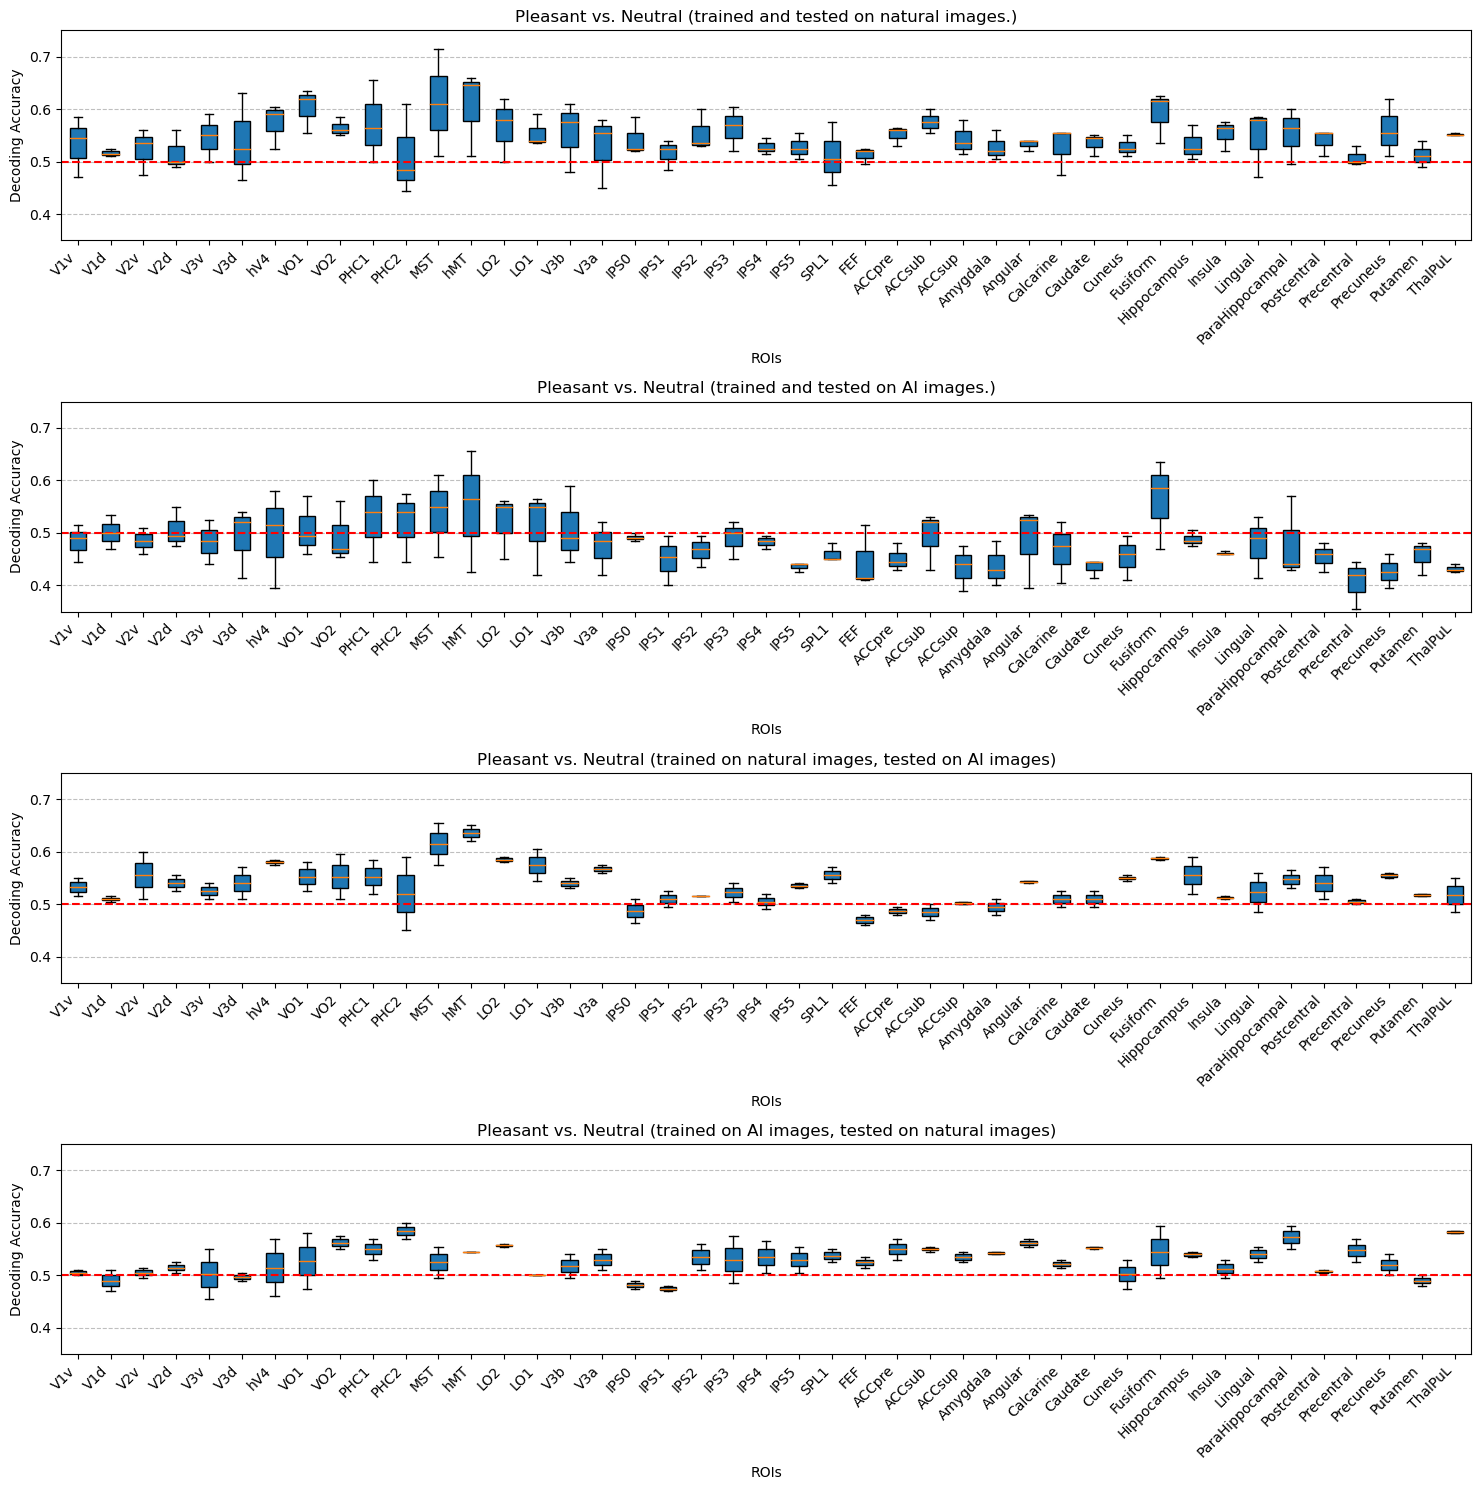

In [25]:
# Create a single figure with three subplots
fig, axes = plt.subplots(4, 1, figsize=(15, 15))  # 3 rows, 1 column

# Within, NATURAL
axes[0].boxplot(rois_all[0,:,:].T, vert=True, patch_artist=True, labels=final_rois)
axes[0].set_xlabel('ROIs')
axes[0].set_ylabel('Decoding Accuracy')
axes[0].set_title('Pleasant vs. Neutral (trained and tested on natural images.)')
axes[0].set_xticklabels(final_rois, rotation=45, ha='right')
axes[0].yaxis.grid(True, linestyle='--', which='major', color='gray', alpha=0.5)
axes[0].axhline(y=0.5, color='red', linestyle='--')
axes[0].set_ylim(0.35, 0.75)

# Within, AI
axes[1].boxplot(rois_all[3,:,:].T, vert=True, patch_artist=True, labels=final_rois)
axes[1].set_xlabel('ROIs')
axes[1].set_ylabel('Decoding Accuracy')
axes[1].set_title('Pleasant vs. Neutral (trained and tested on AI images.)')
axes[1].set_xticklabels(final_rois, rotation=45, ha='right')
axes[1].yaxis.grid(True, linestyle='--', which='major', color='gray', alpha=0.5)
axes[1].axhline(y=0.5, color='red', linestyle='--')
axes[1].set_ylim(0.35, 0.75)

# Cross-condition, NATURAL
axes[2].boxplot(rois_all_xdeco[0,:,:2].T, vert=True, patch_artist=True, labels=final_rois)
axes[2].set_xlabel('ROIs')
axes[2].set_ylabel('Decoding Accuracy')
axes[2].set_title('Pleasant vs. Neutral (trained on natural images, tested on AI images)')
axes[2].set_xticklabels(final_rois, rotation=45, ha='right')
axes[2].yaxis.grid(True, linestyle='--', which='major', color='gray', alpha=0.5)
axes[2].axhline(y=0.5, color='red', linestyle='--')
axes[2].set_ylim(0.35, 0.75)

# Cross-condition, AI
axes[3].boxplot(rois_all_xdeco[3,:,:2].T, vert=True, patch_artist=True, labels=final_rois)
axes[3].set_xlabel('ROIs')
axes[3].set_ylabel('Decoding Accuracy')
axes[3].set_title('Pleasant vs. Neutral (trained on AI images, tested on natural images)')
axes[3].set_xticklabels(final_rois, rotation=45, ha='right')
axes[3].yaxis.grid(True, linestyle='--', which='major', color='gray', alpha=0.5)
axes[3].axhline(y=0.5, color='red', linestyle='--')
axes[3].set_ylim(0.35, 0.75)

# Adjust spacing between subplots
plt.tight_layout()

# Show the combined figure with all three subplots
plt.show()

## Pleasant vs. Unpleasant

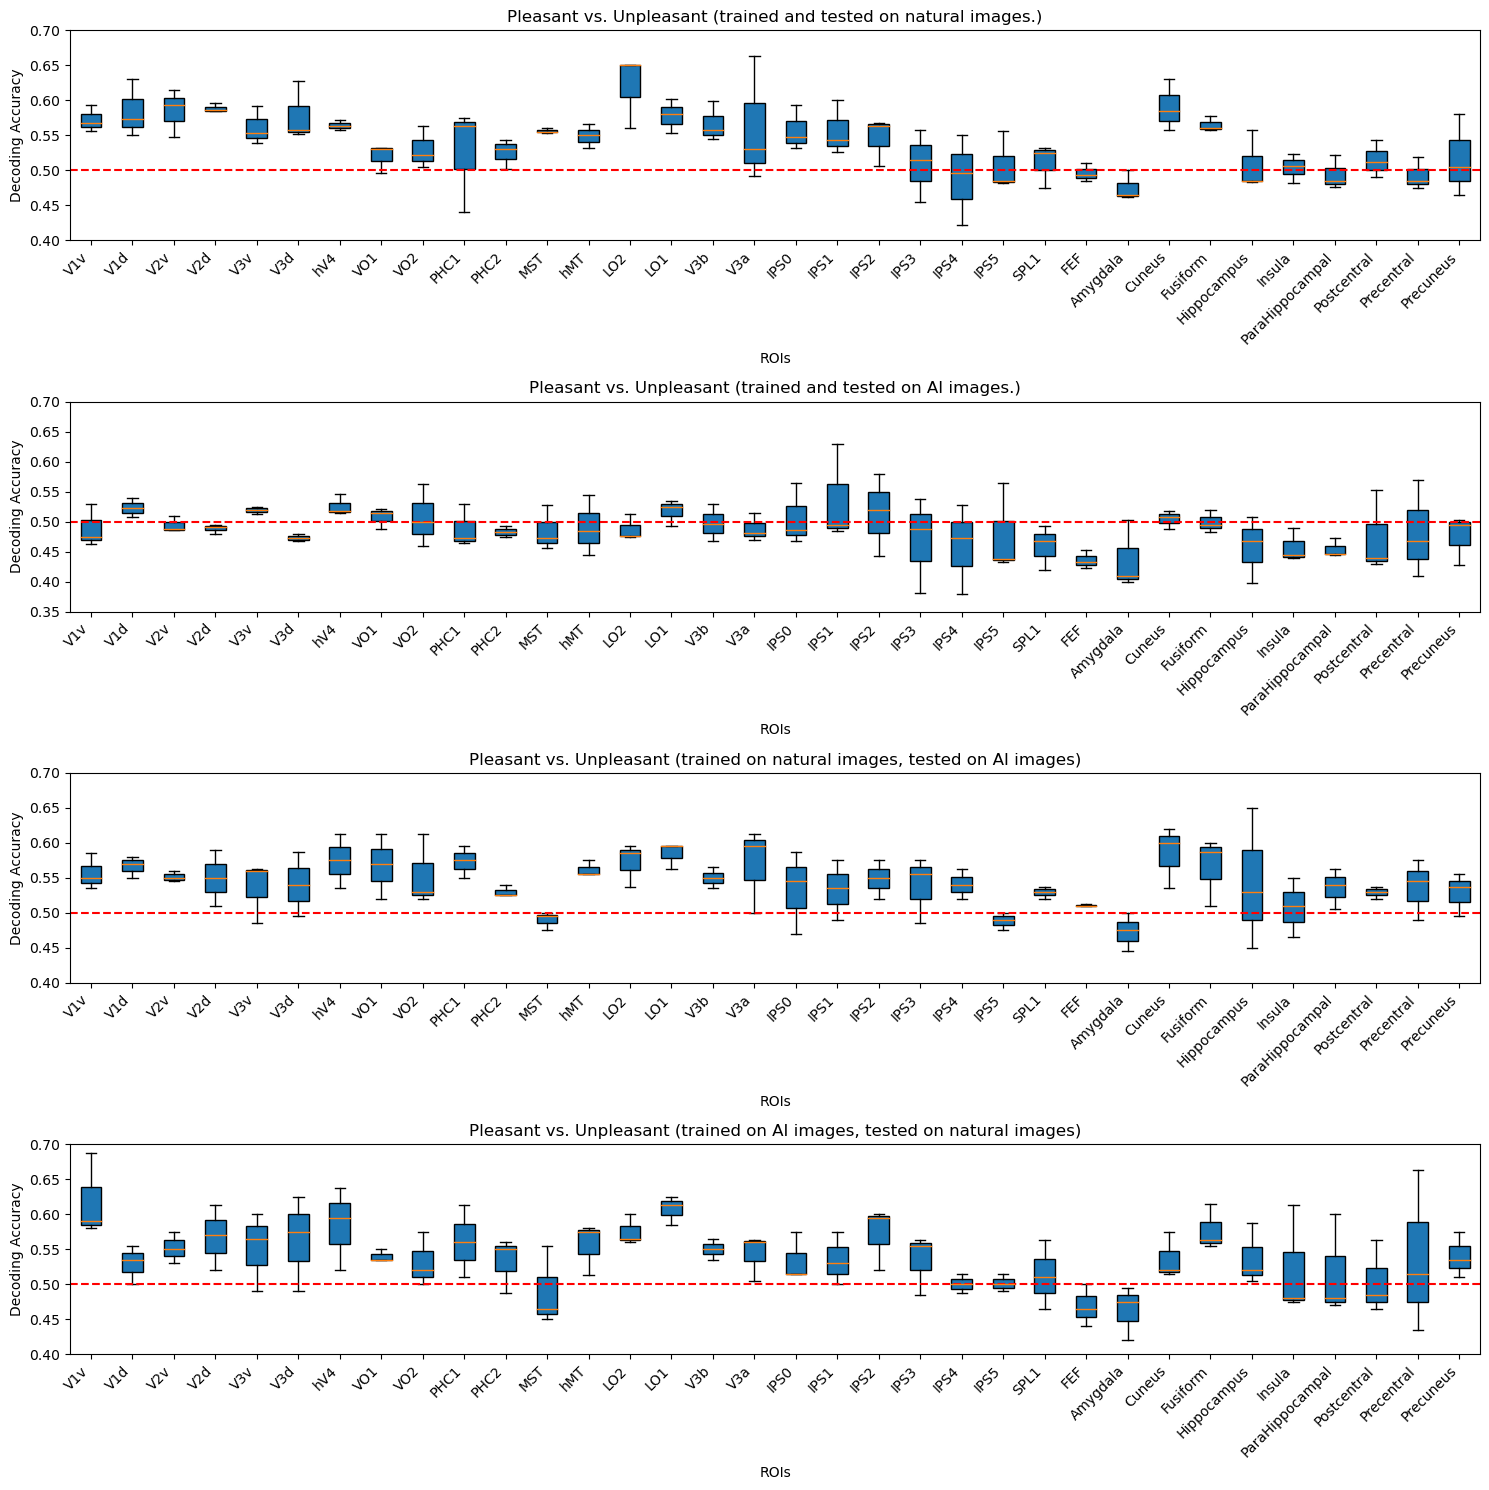

In [170]:
# Create a single figure with three subplots
fig, axes = plt.subplots(4, 1, figsize=(15, 15))  # 3 rows, 1 column

# First subplot
axes[0].boxplot(rois_all[:,:,4], vert=True, patch_artist=True, labels=final_rois)
axes[0].set_xlabel('ROIs')
axes[0].set_ylabel('Decoding Accuracy')
axes[0].set_title('Pleasant vs. Unpleasant (trained and tested on natural images.)')
axes[0].set_xticklabels(final_rois, rotation=45, ha='right')
axes[0].axhline(y=0.5, color='red', linestyle='--')
axes[0].set_ylim(0.4, 0.7)

# First subplot
axes[1].boxplot(rois_all[:,:,7], vert=True, patch_artist=True, labels=final_rois)
axes[1].set_xlabel('ROIs')
axes[1].set_ylabel('Decoding Accuracy')
axes[1].set_title('Pleasant vs. Unpleasant (trained and tested on AI images.)')
axes[1].set_xticklabels(final_rois, rotation=45, ha='right')
axes[1].axhline(y=0.5, color='red', linestyle='--')
axes[1].set_ylim(0.35, 0.7)

# Second subplot
axes[2].boxplot(rois_all_xdeco[:,:,1], vert=True, patch_artist=True, labels=final_rois)
axes[2].set_xlabel('ROIs')
axes[2].set_ylabel('Decoding Accuracy')
axes[2].set_title('Pleasant vs. Unpleasant (trained on natural images, tested on AI images)')
axes[2].set_xticklabels(final_rois, rotation=45, ha='right')
axes[2].axhline(y=0.5, color='red', linestyle='--')
axes[2].set_ylim(0.4, 0.7)

# Third subplot
axes[3].boxplot(rois_all_xdeco[:,:,4], vert=True, patch_artist=True, labels=final_rois)
axes[3].set_xlabel('ROIs')
axes[3].set_ylabel('Decoding Accuracy')
axes[3].set_title('Pleasant vs. Unpleasant (trained on AI images, tested on natural images)')
axes[3].set_xticklabels(final_rois, rotation=45, ha='right')
axes[3].axhline(y=0.5, color='red', linestyle='--')
axes[3].set_ylim(0.4, 0.7)

# Adjust spacing between subplots
plt.tight_layout()

# Show the combined figure with all three subplots
plt.show()

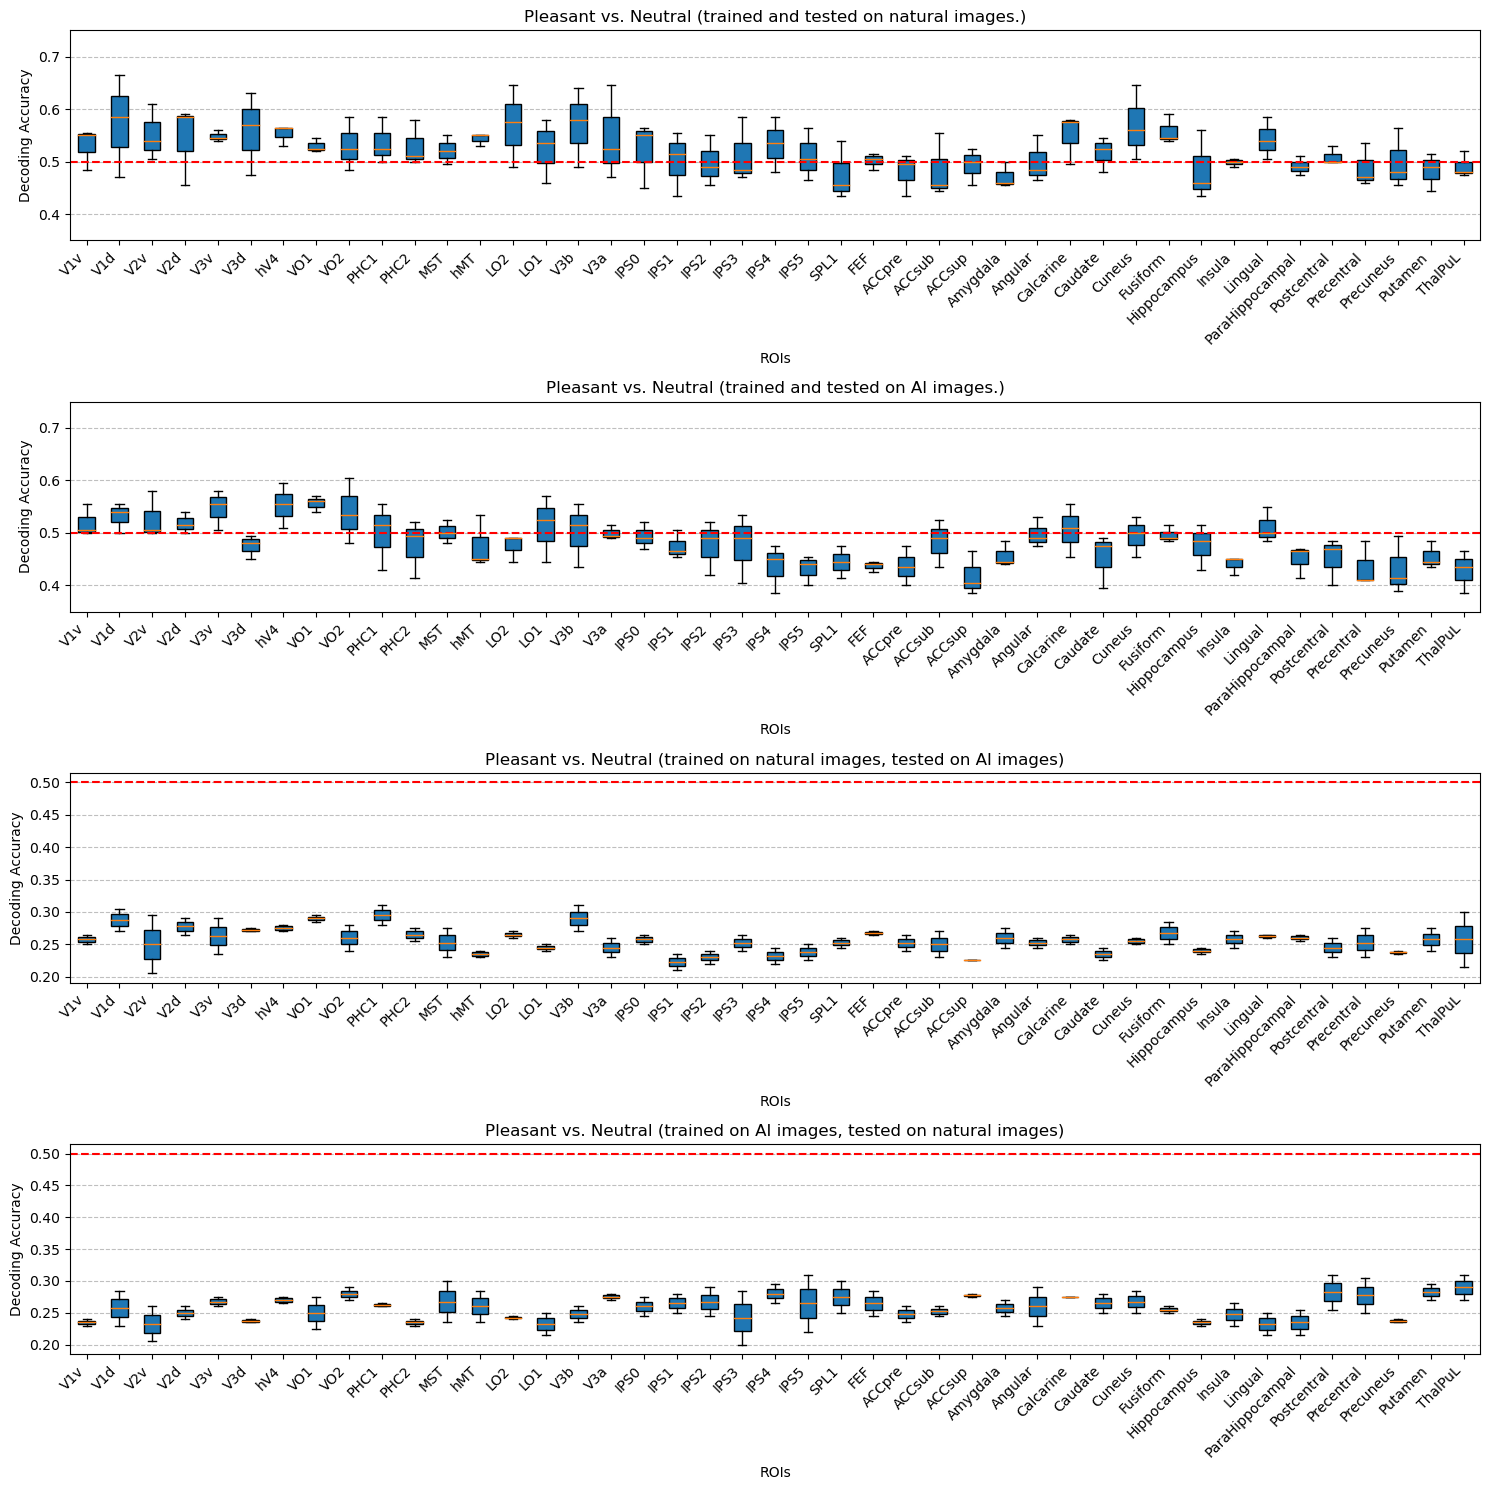

In [32]:
# Create a single figure with three subplots
fig, axes = plt.subplots(4, 1, figsize=(15, 15))  # 3 rows, 1 column

# Within, NATURAL
axes[0].boxplot(rois_all[1,:,:].T, vert=True, patch_artist=True, labels=final_rois)
axes[0].set_xlabel('ROIs')
axes[0].set_ylabel('Decoding Accuracy')
axes[0].set_title('Pleasant vs. Neutral (trained and tested on natural images.)')
axes[0].set_xticklabels(final_rois, rotation=45, ha='right')
axes[0].yaxis.grid(True, linestyle='--', which='major', color='gray', alpha=0.5)
axes[0].axhline(y=0.5, color='red', linestyle='--')
axes[0].set_ylim(0.35, 0.75)

# Within, AI
axes[1].boxplot(rois_all[4,:,:].T, vert=True, patch_artist=True, labels=final_rois)
axes[1].set_xlabel('ROIs')
axes[1].set_ylabel('Decoding Accuracy')
axes[1].set_title('Pleasant vs. Neutral (trained and tested on AI images.)')
axes[1].set_xticklabels(final_rois, rotation=45, ha='right')
axes[1].yaxis.grid(True, linestyle='--', which='major', color='gray', alpha=0.5)
axes[1].axhline(y=0.5, color='red', linestyle='--')
axes[1].set_ylim(0.35, 0.75)

# Cross-condition, NATURAL
axes[2].boxplot(rois_all_xdeco[1,:,:2].T, vert=True, patch_artist=True, labels=final_rois)
axes[2].set_xlabel('ROIs')
axes[2].set_ylabel('Decoding Accuracy')
axes[2].set_title('Pleasant vs. Neutral (trained on natural images, tested on AI images)')
axes[2].set_xticklabels(final_rois, rotation=45, ha='right')
axes[2].yaxis.grid(True, linestyle='--', which='major', color='gray', alpha=0.5)
axes[2].axhline(y=0.5, color='red', linestyle='--')
# axes[2].set_ylim(0.35, 0.75)

# Cross-condition, AI
axes[3].boxplot(rois_all_xdeco[4,:,:2].T, vert=True, patch_artist=True, labels=final_rois)
axes[3].set_xlabel('ROIs')
axes[3].set_ylabel('Decoding Accuracy')
axes[3].set_title('Pleasant vs. Neutral (trained on AI images, tested on natural images)')
axes[3].set_xticklabels(final_rois, rotation=45, ha='right')
axes[3].yaxis.grid(True, linestyle='--', which='major', color='gray', alpha=0.5)
axes[3].axhline(y=0.5, color='red', linestyle='--')
# axes[3].set_ylim(0.35, 0.75)

# Adjust spacing between subplots
plt.tight_layout()

# Show the combined figure with all three subplots
plt.show()

## Unpleasant vs Neutral

### Same category

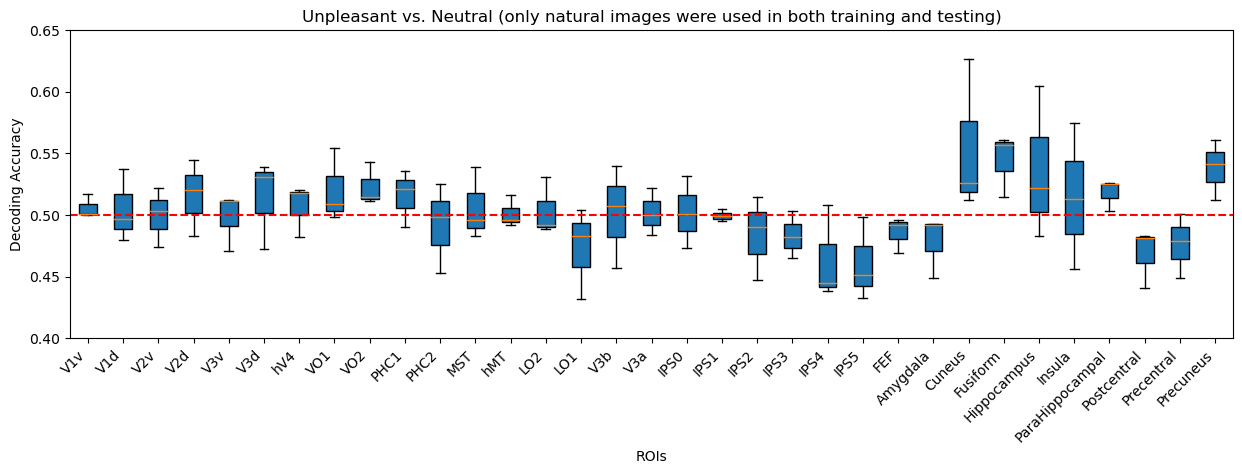

In [126]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.boxplot(rois_all[:,:,5], vert=True, patch_artist=True, labels=final_rois)

# Add labels and title
ax.set_xlabel('ROIs')
ax.set_ylabel('Decoding Accuracy')
ax.set_title('Unpleasant vs. Neutral (only natural images were used in both training and testing)')
ax.set_xticklabels(final_rois, rotation=45, ha='right')

# Add a horizontal reference line at y=0.5
ax.axhline(y=0.5, color='red', linestyle='--')

ax.set_ylim(0.4, 0.65) 
# Show the plot
plt.show()

### Cross category

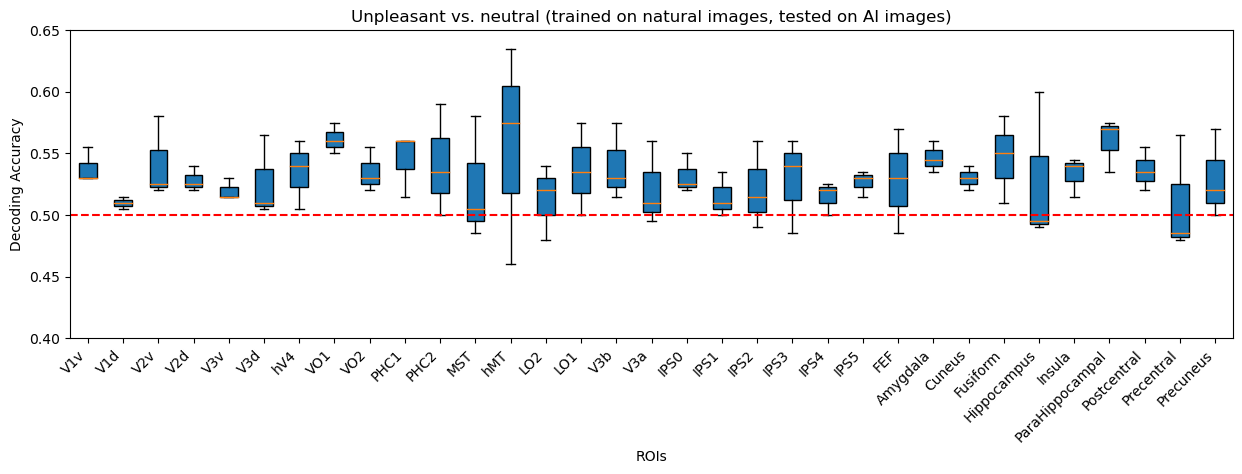

In [125]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.boxplot(rois_all_xdeco[:,:,2], vert=True, patch_artist=True, labels=final_rois)

# Add labels and title
ax.set_xlabel('ROIs')
ax.set_ylabel('Decoding Accuracy')
ax.set_title('Unpleasant vs. neutral (trained on natural images, tested on AI images)')
ax.set_xticklabels(final_rois, rotation=45, ha='right')

# Add a horizontal reference line at y=0.5
ax.axhline(y=0.5, color='red', linestyle='--')

ax.set_ylim(0.4, 0.65) 
# Show the plot
plt.show()

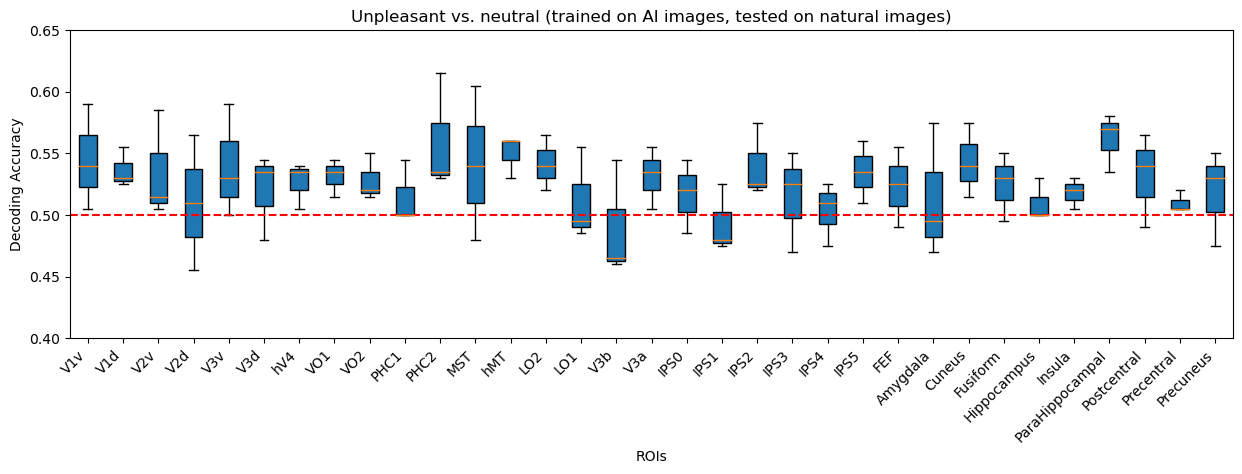

In [124]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.boxplot(rois_all_xdeco[:,:,5], vert=True, patch_artist=True, labels=final_rois)

# Add labels and title
ax.set_xlabel('ROIs')
ax.set_ylabel('Decoding Accuracy')
ax.set_title('Unpleasant vs. neutral (trained on AI images, tested on natural images)')
ax.set_xticklabels(final_rois, rotation=45, ha='right')

# Add a horizontal reference line at y=0.5
ax.axhline(y=0.5, color='red', linestyle='--')

ax.set_ylim(0.4, 0.65) 
# Show the plot
plt.show()

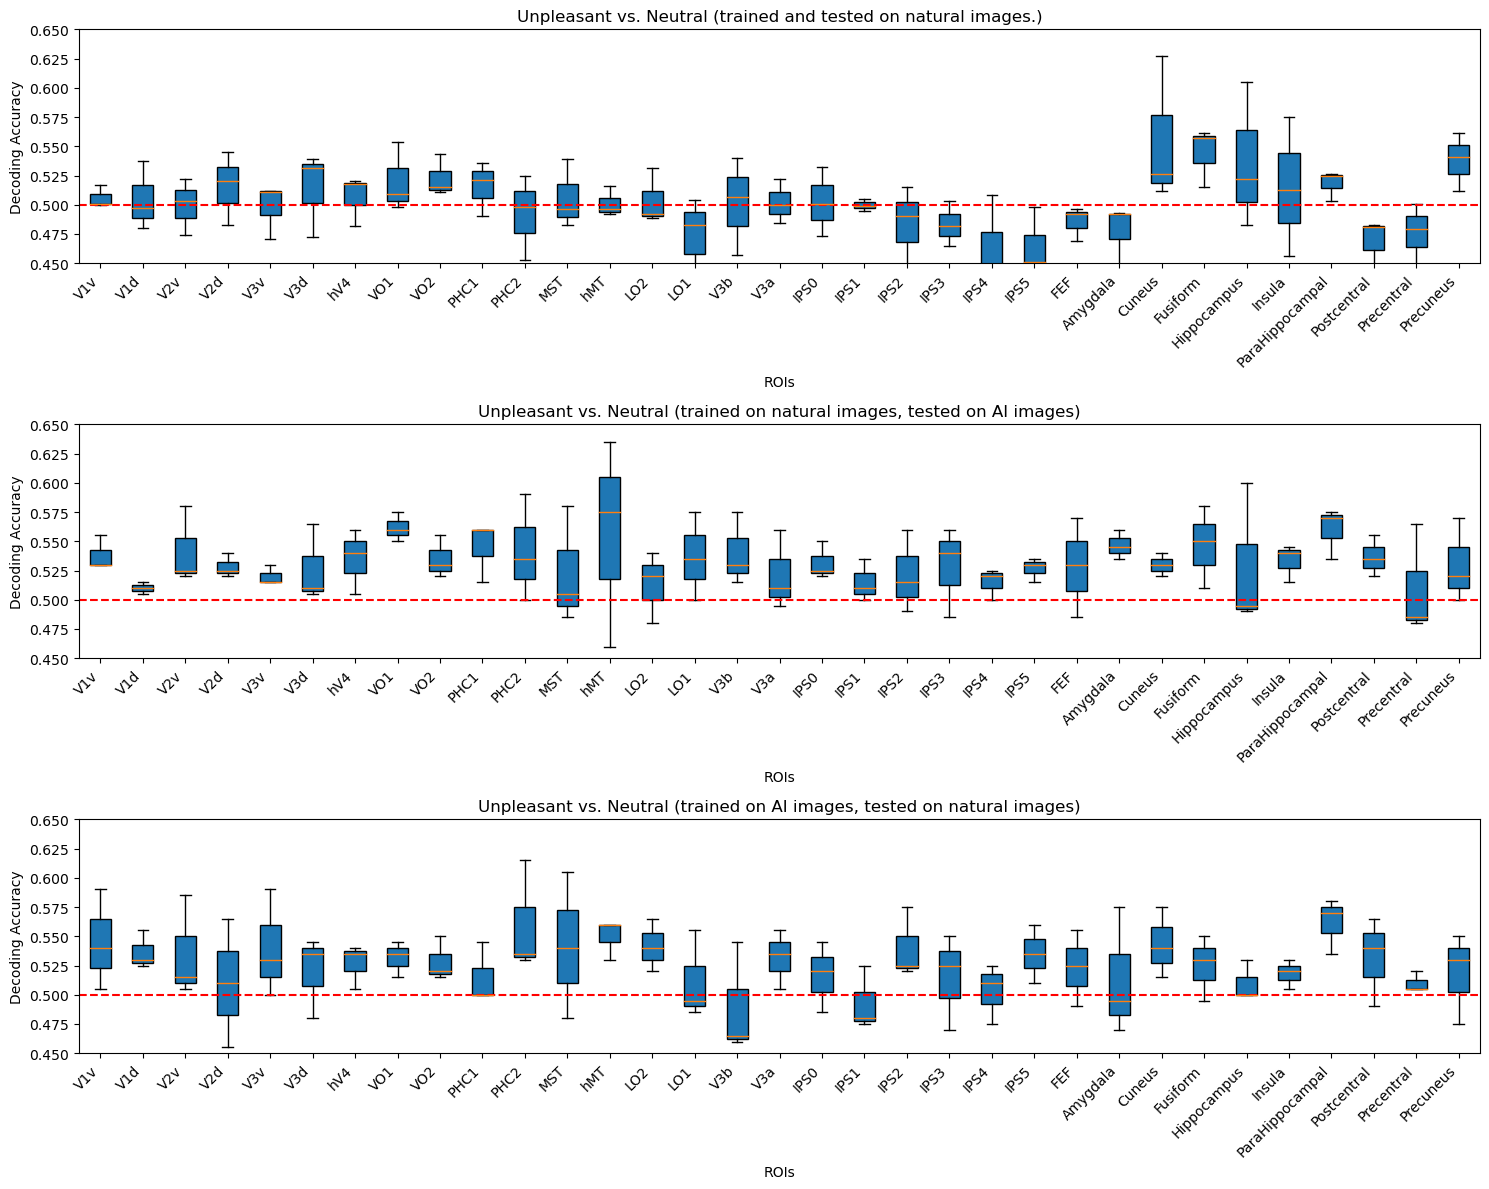

In [141]:
# Create a single figure with three subplots
fig, axes = plt.subplots(3, 1, figsize=(15, 12))  # 3 rows, 1 column

# First subplot
axes[0].boxplot(rois_all[:,:,5], vert=True, patch_artist=True, labels=final_rois)
axes[0].set_xlabel('ROIs')
axes[0].set_ylabel('Decoding Accuracy')
axes[0].set_title('Unpleasant vs. Neutral (trained and tested on natural images.)')
axes[0].set_xticklabels(final_rois, rotation=45, ha='right')
axes[0].axhline(y=0.5, color='red', linestyle='--')
axes[0].set_ylim(0.45, 0.65)

# Second subplot
axes[1].boxplot(rois_all_xdeco[:,:,2], vert=True, patch_artist=True, labels=final_rois)
axes[1].set_xlabel('ROIs')
axes[1].set_ylabel('Decoding Accuracy')
axes[1].set_title('Unpleasant vs. Neutral (trained on natural images, tested on AI images)')
axes[1].set_xticklabels(final_rois, rotation=45, ha='right')
axes[1].axhline(y=0.5, color='red', linestyle='--')
axes[1].set_ylim(0.45, 0.65)

# Third subplot
axes[2].boxplot(rois_all_xdeco[:,:,5], vert=True, patch_artist=True, labels=final_rois)
axes[2].set_xlabel('ROIs')
axes[2].set_ylabel('Decoding Accuracy')
axes[2].set_title('Unpleasant vs. Neutral (trained on AI images, tested on natural images)')
axes[2].set_xticklabels(final_rois, rotation=45, ha='right')
axes[2].axhline(y=0.5, color='red', linestyle='--')
axes[2].set_ylim(0.45, 0.65)

# Adjust spacing between subplots
plt.tight_layout()

# Show the combined figure with all three subplots
plt.show()

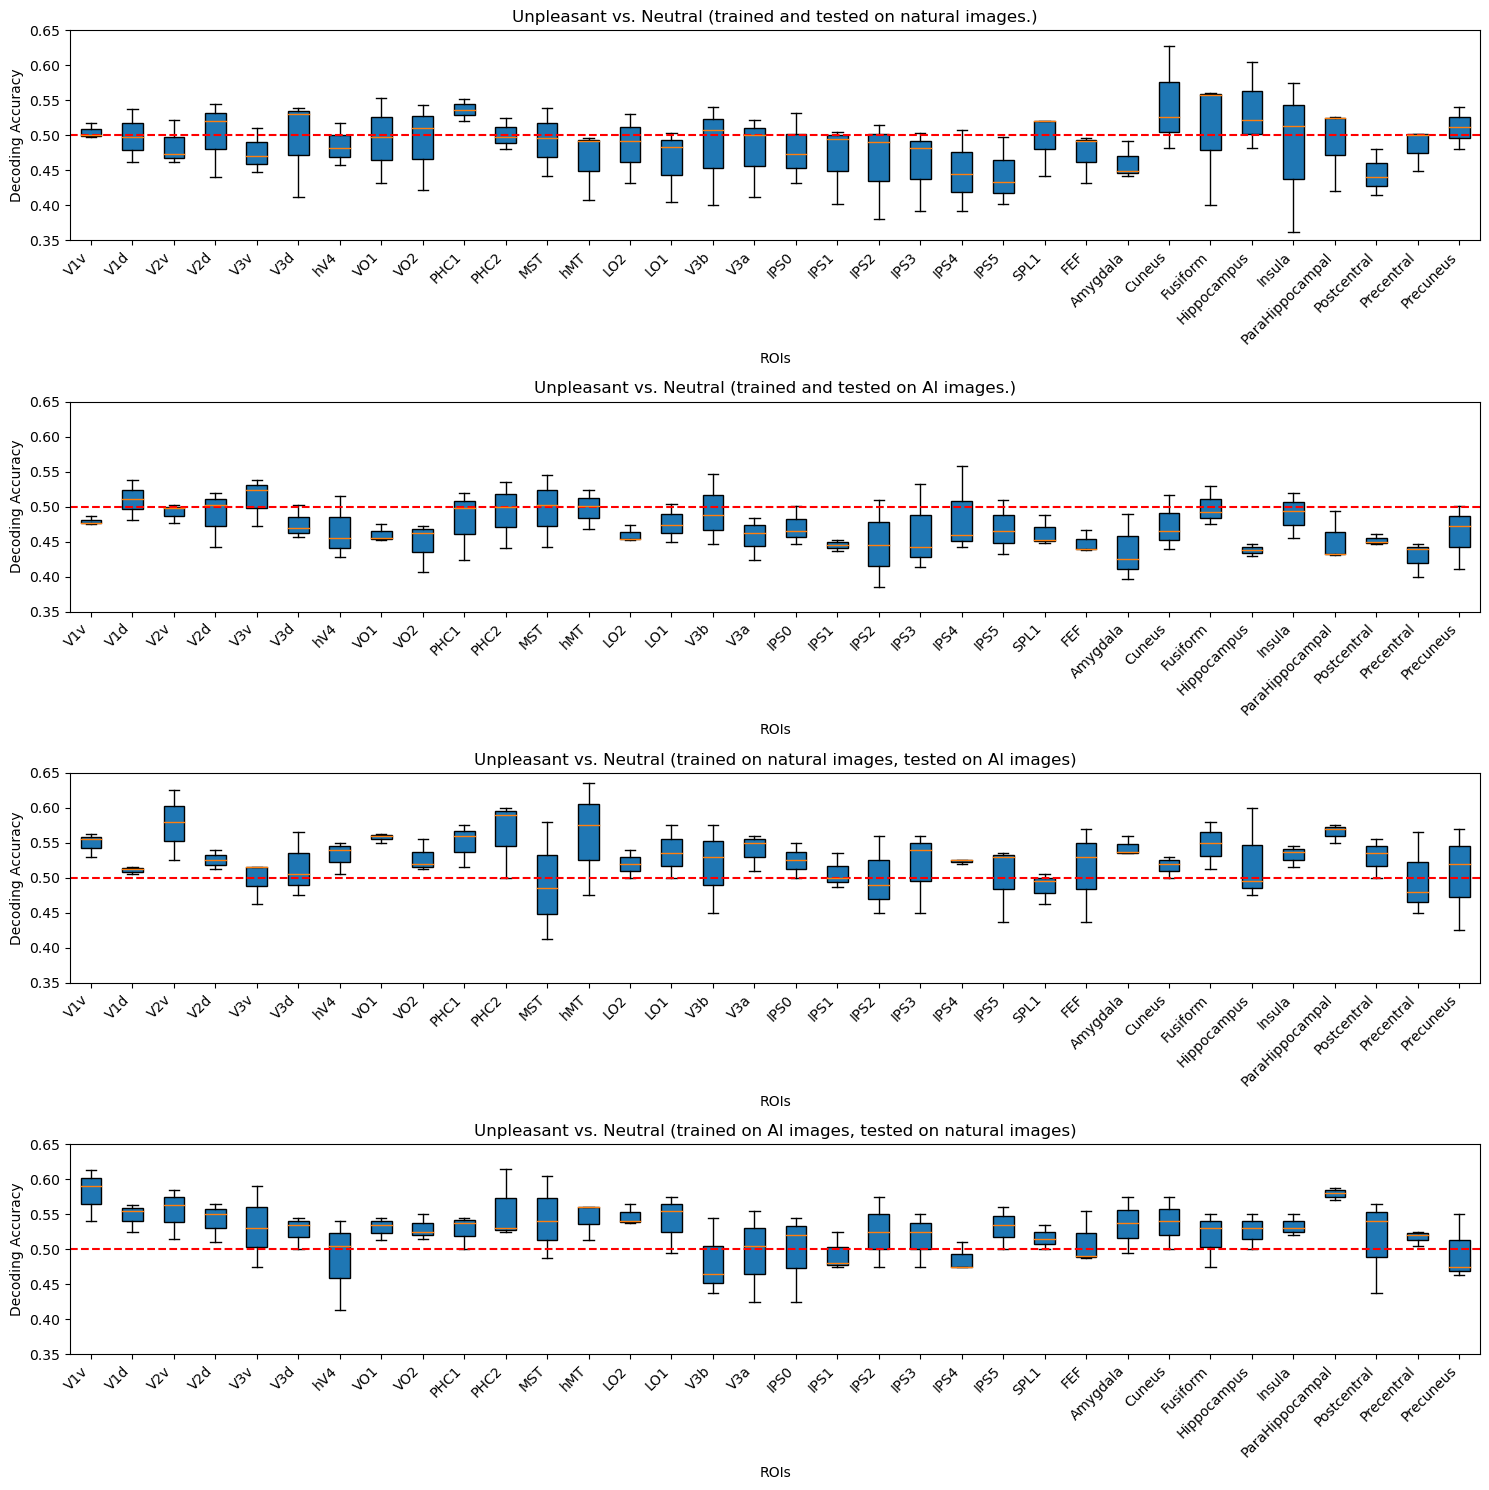

In [172]:
# Create a single figure with three subplots
fig, axes = plt.subplots(4, 1, figsize=(15, 15))  # 3 rows, 1 column

# First subplot
axes[0].boxplot(rois_all[:,:,5], vert=True, patch_artist=True, labels=final_rois)
axes[0].set_xlabel('ROIs')
axes[0].set_ylabel('Decoding Accuracy')
axes[0].set_title('Unpleasant vs. Neutral (trained and tested on natural images.)')
axes[0].set_xticklabels(final_rois, rotation=45, ha='right')
axes[0].axhline(y=0.5, color='red', linestyle='--')
axes[0].set_ylim(0.35, 0.65)

# First subplot
axes[1].boxplot(rois_all[:,:,8], vert=True, patch_artist=True, labels=final_rois)
axes[1].set_xlabel('ROIs')
axes[1].set_ylabel('Decoding Accuracy')
axes[1].set_title('Unpleasant vs. Neutral (trained and tested on AI images.)')
axes[1].set_xticklabels(final_rois, rotation=45, ha='right')
axes[1].axhline(y=0.5, color='red', linestyle='--')
axes[1].set_ylim(0.35, 0.65)

# Second subplot
axes[2].boxplot(rois_all_xdeco[:,:,2], vert=True, patch_artist=True, labels=final_rois)
axes[2].set_xlabel('ROIs')
axes[2].set_ylabel('Decoding Accuracy')
axes[2].set_title('Unpleasant vs. Neutral (trained on natural images, tested on AI images)')
axes[2].set_xticklabels(final_rois, rotation=45, ha='right')
axes[2].axhline(y=0.5, color='red', linestyle='--')
axes[2].set_ylim(0.35, 0.65)

# Third subplot
axes[3].boxplot(rois_all_xdeco[:,:,5], vert=True, patch_artist=True, labels=final_rois)
axes[3].set_xlabel('ROIs')
axes[3].set_ylabel('Decoding Accuracy')
axes[3].set_title('Unpleasant vs. Neutral (trained on AI images, tested on natural images)')
axes[3].set_xticklabels(final_rois, rotation=45, ha='right')
axes[3].axhline(y=0.5, color='red', linestyle='--')
axes[3].set_ylim(0.35, 0.65)

# Adjust spacing between subplots
plt.tight_layout()

# Show the combined figure with all three subplots
plt.show()